In [9]:
import pandas as pd
import seaborn as sns
data = pd.read_csv('C:/Users/HP/Downloads/insurance.csv')
df = pd.DataFrame(data)
df.info

####-------feature engineering
X = df.drop(columns=['charges'])
X = pd.get_dummies(X,columns=['region'],drop_first=True,dtype=int)
Y = df['charges']

####-----encoding
X['smoker'] = X['smoker'].map({'yes':1,'no':0})
X['sex']    = X['sex'].map({'female':0,'male':1})

####----------train-test data
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

####----------model training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,Y_train)

####-----------
y_pred = model.predict(X_test)

###----------
from sklearn.metrics import r2_score
r2  = r2_score(y_pred,Y_test)
r2

0.708835127719835

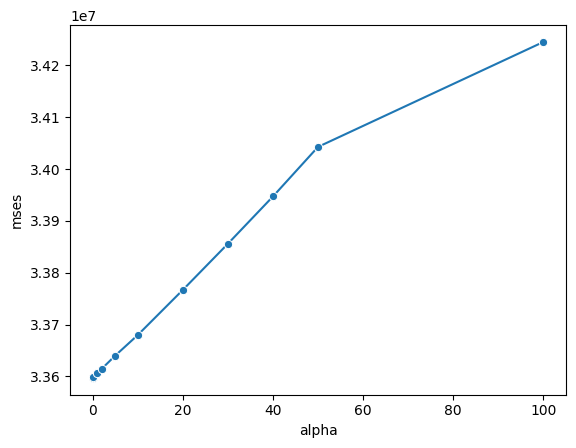

In [21]:
####---------using lasso regression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
# from sklearn
alpha = [0.001,0.1,1,2,5,10,20,30,40,50,100]
mses = []

for a in alpha:
    lasso_model = Lasso(a)
    lasso_model.fit(X_train,Y_train)
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(Y_test,y_pred)
    mses.append(mse)

import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(x=alpha,y=mses,marker='o')
plt.xlabel('alpha')
plt.ylabel('mses')
plt.show()

In [30]:
####----------using lasso cv
from sklearn.linear_model import LassoCV
alphas = [0.001,0.1,1,2,5,10,20,30,40,50,100]
LassoCV_model = LassoCV(alphas=a , cv=5,max_iter=100,random_state=42)
LassoCV_model.fit(X_train,Y_train)

y_pred = LassoCV_model.predict(X_test)

print(f'best alpha value{LassoCV_model.alpha_}')

mse = mean_squared_error(y_pred,Y_test)
mse


best alpha value89.2161025213486


34210457.68943394